# 03 — Attention, from scratch

Goal: we are gonna understand and implement scaled dot-product self-attention with our
own hands — no `nn.MultiheadAttention`. We go in three passes:

1. Raw tensor math on a tiny toy example (see every shape, every step)
2. Wrap it into a `Head` module
3. Stack heads into `MultiHeadAttention`

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(1337)  #PyTorch's random seed

## Part 1 — Raw math on a toy example

Imagine a tiny batch: 1 sequence, 4 tokens, embedding dim 8. We'll compute
self-attention by hand, printing shapes at every step so nothing is hidden.

In [3]:
B, T, C = 1, 4, 8   # batch, time (sequence length), channels (embedding dim)
x = torch.randn(B, T, C)
print('input x:', x.shape)

input x: torch.Size([1, 4, 8])


In [8]:
print(x)

tensor([[[ 0.1808, -0.0700, -0.3596, -0.9152,  0.6258,  0.0255,  0.9545,
           0.0643],
         [ 0.3612,  1.1679, -1.3499, -0.5102,  0.2360, -0.2398, -0.9211,
           1.5433],
         [ 1.3488, -0.1396,  0.2858,  0.9651, -2.0371,  0.4931,  1.4870,
           0.5910],
         [ 0.1260, -1.5627, -1.1601, -0.3348,  0.4478, -0.8016,  1.5236,
           2.5086]]])


### Step 1: project x into Query, Key, Value

These are just three separate linear layers. Q asks "what am I looking for?",
K answers "what do I contain?", V is "what do I actually pass along if chosen".

In [4]:
head_size = 8
key   = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k = key(x)     # (B, T, head_size)
q = query(x)   # (B, T, head_size)
v = value(x)   # (B, T, head_size)
print('k:', k.shape, 'q:', q.shape, 'v:', v.shape)

k: torch.Size([1, 4, 8]) q: torch.Size([1, 4, 8]) v: torch.Size([1, 4, 8])


### Step 2: raw attention scores

For every query position, compare it against every key position via a dot
product. Result: a (T, T) matrix — `wei[i][j]` = how much token i attends to token j.

In [7]:
wei = q @ k.transpose(-2, -1)   # (B, T, head_size) @ (B, head_size, T) -> (B, T, T)
print('raw scores shape:', wei.shape)
print(wei[0])

raw scores shape: torch.Size([1, 4, 4])
tensor([[ 0.0297,  0.4469, -0.1781,  0.0778],
        [-0.3746,  0.8066, -1.1711,  0.5151],
        [ 1.3599, -0.1601,  0.5338,  0.5709],
        [ 0.8120,  2.0889, -0.6692,  1.7924]], grad_fn=<SelectBackward0>)


### Step 3: scale by 1/sqrt(head_size)

Without this, scores grow with `head_size` and push softmax into regions
with near-zero gradients (it saturates to one-hot). Scaling keeps the
variance roughly stable regardless of head_size.

In [9]:
wei = wei * head_size**-0.5
print(wei[0])

tensor([[ 0.0105,  0.1580, -0.0630,  0.0275],
        [-0.1324,  0.2852, -0.4140,  0.1821],
        [ 0.4808, -0.0566,  0.1887,  0.2019],
        [ 0.2871,  0.7385, -0.2366,  0.6337]], grad_fn=<SelectBackward0>)


### Step 4: the causal mask

Token i must not see tokens after position i — otherwise the model could
'cheat' during training by peeking at the future it's supposed to predict.
We set illegal positions to `-inf` before softmax, so they become exactly 0
probability after softmax.

In [11]:
tril = torch.tril(torch.ones(T, T))  #The triangular mask
print('mask:')
print(tril)

wei = wei.masked_fill(tril == 0, float('-inf'))
print()
print('masked scores:')
print(wei[0])

mask:
tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])

masked scores:
tensor([[ 0.0105,    -inf,    -inf,    -inf],
        [-0.1324,  0.2852,    -inf,    -inf],
        [ 0.4808, -0.0566,  0.1887,    -inf],
        [ 0.2871,  0.7385, -0.2366,  0.6337]], grad_fn=<SelectBackward0>)


### Step 5: softmax — turn scores into a probability distribution per row

Each row now sums to 1. Row i is 'how much token i attends to tokens 0..i'.

In [12]:
wei = F.softmax(wei, dim=-1)
print(wei[0])
print('row sums (should all be 1.0):', wei[0].sum(dim=-1))

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.3971, 0.6029, 0.0000, 0.0000],
        [0.4290, 0.2507, 0.3203, 0.0000],
        [0.2185, 0.3431, 0.1294, 0.3090]], grad_fn=<SelectBackward0>)
row sums (should all be 1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)


### Step 6: weighted sum of Values

This is the actual output: each token's new representation is a weighted
blend of the Value vectors of the tokens it's allowed to attend to.

In [13]:
out = wei @ v   # (B, T, T) @ (B, T, head_size) -> (B, T, head_size)
print('output shape:', out.shape)

output shape: torch.Size([1, 4, 8])


In [14]:
out

tensor([[[ 0.2670, -0.1756,  0.1955, -0.0063, -0.4604,  0.4809,  0.1541,
           0.3029],
         [ 0.4788, -0.3830,  0.3546, -0.1472, -0.4339,  0.2593,  0.1091,
           0.0854],
         [ 0.1439,  0.0327,  0.3926, -0.3558, -0.6889, -0.2466, -0.0229,
           0.0398],
         [ 0.4853, -0.0126,  0.4567, -0.2459, -0.9087, -0.2402,  0.0866,
           0.4976]]], grad_fn=<UnsafeViewBackward0>)

### Visualize the attention pattern

With the causal mask, this should look strictly lower-triangular — token 0
only attends to itself, token 3 attends to all 4 positions.

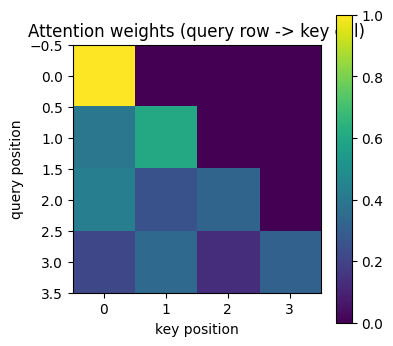

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.imshow(wei[0].detach().numpy(), cmap='viridis')
plt.colorbar()
plt.title('Attention weights (query row -> key col)')
plt.xlabel('key position')
plt.ylabel('query position')
plt.show()

## Part 2 — Wrap it into a `Head` module

Same six steps as above, just packaged so it can be reused and stacked.

In [16]:
class Head(nn.Module):
    """One self-attention head."""

    def __init__(self, n_embd, head_size, block_size, dropout):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # not a learnable parameter, but should move with .to(device) and be saved/loaded
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        wei = q @ k.transpose(-2, -1) * k.shape[-1]**-0.5   # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        out = wei @ v   # (B, T, head_size)
        return out

In [17]:
# sanity check: does it reproduce Part 1's output shape?
head = Head(n_embd=C, head_size=head_size, block_size=T, dropout=0.0)
test_out = head(x)
print('Head output shape:', test_out.shape)   # expect (1, 4, 8)

Head output shape: torch.Size([1, 4, 8])


## Part 3 — Multi-head attention

Instead of one attention computation, run several smaller ones ('heads') in
parallel, each free to learn a different notion of relevance (e.g. one head
might track 'matching brackets', another 'the variable this refers to').
Concatenate their outputs and project back to `n_embd`.

In [20]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        assert n_embd % n_head == 0, 'n_embd must be divisible by n_head'
        head_size = n_embd // n_head
        self.heads = nn.ModuleList([
            Head(n_embd, head_size, block_size, dropout) for _ in range(n_head)
        ])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)   # (B, T, n_embd)
        out = self.dropout(self.proj(out))
        return out

In [23]:
import os
if not os.path.exists('MiniGPT'):
    !git clone https://github.com/userKk1/MiniGPT.git
%cd MiniGPT

Cloning into 'MiniGPT'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 61 (delta 25), reused 39 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 52.47 KiB | 8.74 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/MiniGPT


In [24]:
from config import cfg

mha = MultiHeadAttention(
    n_embd=cfg.model.n_embd,
    n_head=cfg.model.n_head,
    block_size=cfg.model.block_size,
    dropout=cfg.model.dropout,
)

dummy = torch.randn(2, cfg.model.block_size, cfg.model.n_embd)  # (batch=2, T=block_size, C=n_embd)
out = mha(dummy)
print('input :', dummy.shape)
print('output:', out.shape)   # must match input shape -- this is what makes the residual connection work
assert out.shape == dummy.shape

input : torch.Size([2, 256, 256])
output: torch.Size([2, 256, 256])


In [25]:
out

tensor([[[-3.8765e-01,  4.5203e-01, -5.9476e-03,  ..., -1.6971e-01,
          -1.5784e-01,  5.2551e-01],
         [ 7.3712e-02, -3.2792e-01, -0.0000e+00,  ..., -2.2759e-01,
          -1.7877e-01,  3.6765e-01],
         [-1.6118e-01,  1.3463e-02, -1.3955e-01,  ..., -7.6729e-02,
          -3.1165e-01, -0.0000e+00],
         ...,
         [ 3.6793e-03,  5.9538e-02, -8.6061e-02,  ..., -6.8716e-02,
          -2.9318e-03, -4.7468e-02],
         [ 1.6939e-02,  8.6442e-02, -7.2658e-02,  ..., -5.9481e-02,
          -5.0946e-02, -3.3687e-02],
         [-1.0573e-04,  5.4092e-02, -8.5933e-02,  ..., -7.4251e-02,
          -6.2132e-02, -0.0000e+00]],

        [[-0.0000e+00,  2.1520e-01,  2.3859e-01,  ..., -1.4627e-01,
           3.2924e-01,  1.7478e-02],
         [-2.3750e-01,  1.1715e-01,  6.3738e-01,  ..., -3.3894e-02,
           5.9753e-02, -4.6005e-01],
         [ 1.9935e-02, -6.9945e-02,  2.1433e-01,  ..., -3.2949e-01,
          -0.0000e+00, -8.4556e-03],
         ...,
         [ 0.0000e+00,  2